In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.distributions import Normal

torch.set_default_dtype(torch.float64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
# Snelson-like dataset

n_dense = 140
n_left = 20
n_right = 20

x_dense = np.random.uniform(0.0, 6.0, size=n_dense)
x_left = np.random.uniform(-4.0, 0.0, size=n_left)
x_right = np.random.uniform(6.0, 10.0, size=n_right)

x_all = np.concatenate([x_left, x_dense, x_right])
x_all = np.sort(x_all)

def f_true(x):
    return np.sin(x) + 0.3 * np.cos(3.0 * x)

noise_std_true = 0.15
y_all = f_true(x_all) + noise_std_true * np.random.randn(len(x_all))

# remove points in the gap
mask = (x_all < 1.5) | (x_all > 3.0)

x_train = x_all[mask][:, None]
y_train = y_all[mask][:, None]

x_test = np.linspace(-4.0, 10.0, 500)[:, None]
y_test_true = f_true(x_test[:, 0])[:, None]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)

x_train shape: (146, 1)
y_train shape: (146, 1)
x_test shape : (500, 1)


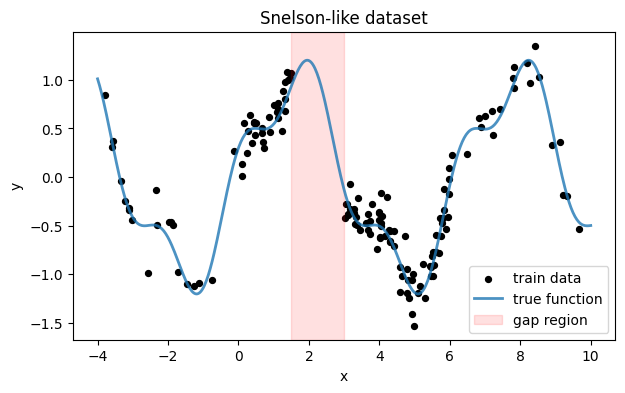

x_mean, x_std: 3.2727323254784335 3.170732719988017
y_mean, y_std: -0.16637605445004164 0.6779489264219345


In [3]:
# Visualisation des données
plt.figure(figsize=(7, 4))
plt.scatter(x_train[:, 0], y_train[:, 0], s=18, color='black', label='train data')
plt.plot(x_test[:, 0], y_test_true[:, 0], linewidth=2, alpha=0.8, label='true function')
plt.axvspan(1.5, 3.0, color='red', alpha=0.12, label='gap region')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Snelson-like dataset")
plt.legend()
plt.show()

# Standardisation
x_mean, x_std = x_train.mean(), x_train.std()
y_mean, y_std = y_train.mean(), y_train.std()

x_train_std = (x_train - x_mean) / x_std
y_train_std = (y_train - y_mean) / y_std
x_test_std = (x_test - x_mean) / x_std

print("x_mean, x_std:", float(x_mean), float(x_std))
print("y_mean, y_std:", float(y_mean), float(y_std))

In [4]:
# Tensors
X_train = torch.tensor(x_train_std, dtype=torch.float64, device=device)
Y_train = torch.tensor(y_train_std, dtype=torch.float64, device=device)
X_test = torch.tensor(x_test_std, dtype=torch.float64, device=device)

# 1 hidden layer, 32 units, sigmoid
class MLP(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=32, out_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h = self.act(self.fc1(x))
        return self.fc2(h)

model = MLP().to(device)

# helpers
def num_params(model):
    return sum(p.numel() for p in model.parameters())

def flatten_params(model):
    return torch.cat([p.detach().reshape(-1) for p in model.parameters()])

print("Number of parameters:", num_params(model))

Number of parameters: 97


In [5]:
delta = 30.0
sigma_noise = 0.25
lr = 1e-2
n_epochs = 4000

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

loss_history = []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    pred = model(X_train)                     # shape (n,1)
    nll = 0.5 / (sigma_noise**2) * torch.sum((Y_train - pred)**2)

    prior_term = 0.0
    for p in model.parameters():
        prior_term = prior_term + 0.5 * delta * torch.sum(p**2)

    loss = nll + prior_term
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | loss = {loss.item():.4f} | nll = {nll.item():.4f}")

theta_map = flatten_params(model).detach().clone()
print("theta_map shape:", theta_map.shape)

Epoch  500 | loss = 1167.8274 | nll = 1166.0742
Epoch 1000 | loss = 1167.8150 | nll = 1166.2828
Epoch 1500 | loss = 1167.8138 | nll = 1166.2726
Epoch 2000 | loss = 1167.8084 | nll = 1166.2198
Epoch 2500 | loss = 1167.7683 | nll = 1165.8103
Epoch 3000 | loss = 1167.7540 | nll = 1165.6341
Epoch 3500 | loss = 1167.7545 | nll = 1165.6347
Epoch 4000 | loss = 1167.7539 | nll = 1165.6334
theta_map shape: torch.Size([97])


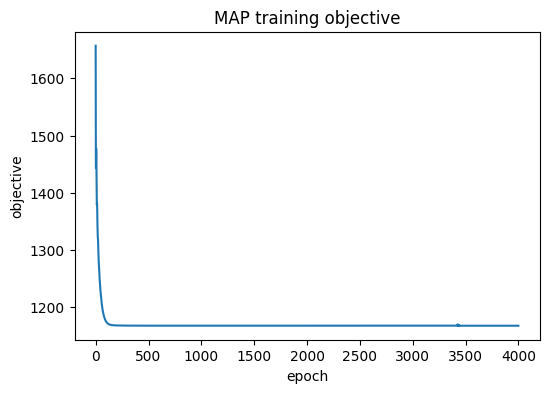

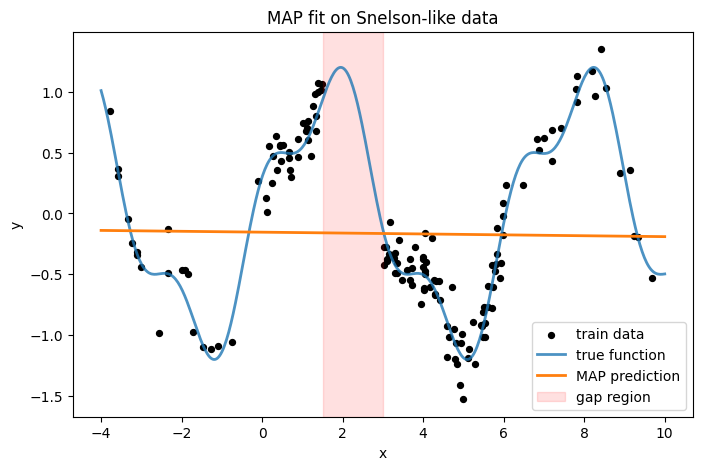

In [6]:
# Courbe de loss
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("objective")
plt.title("MAP training objective")
plt.show()

# Prédiction MAP en espace standardisé
with torch.no_grad():
    y_map_std = model(X_test).cpu().numpy()

# Retour à l'échelle originale
y_map = y_mean + y_std * y_map_std

plt.figure(figsize=(8, 5))
plt.scatter(x_train[:, 0], y_train[:, 0], s=18, color='black', label='train data')
plt.plot(x_test[:, 0], y_test_true[:, 0], linewidth=2, alpha=0.8, label='true function')
plt.plot(x_test[:, 0], y_map[:, 0], linewidth=2, label='MAP prediction')
plt.axvspan(1.5, 3.0, color='red', alpha=0.12, label='gap region')
plt.xlabel("x")
plt.ylabel("y")
plt.title("MAP fit on Snelson-like data")
plt.legend()
plt.show()